# 10 · Detecção sob `aggregation=max` — decisão de default (M9 · #58)

A Fase 2 (notebook 07) mostrou `max` >> `mean` na **injeção sintética** (Recall 0,16→0,35,
Precision 0,55→0,84). Mas o default de produção segue `mean` para preservar os números de
M4–M6. Aqui verificamos o comportamento de `max` nos **dados reais de teste (2020–2024)** ---
fração de janelas marcadas (M4) e P/R/F1 (M5) --- para decidir a troca.

**Risco a checar:** `max` é sensível ao pior passo; com o limiar recalibrado, a fração marcada
no teste real pode explodir (default ruim) ou ficar próxima da taxa-base (~5%, troca segura).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp, train as T, detect as D
from src.evaluate import inject_price_shocks, labels_to_window_labels, compute_metrics
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG['tickers']
W = CONFIG['preprocessing']['window_size']
P = CONFIG['detection'].get('aggregation_percentile', 90)
AGGS = [('mean', None), ('max', None), ('percentile', P)]

pre    = {t: pp.preprocess_ticker(df) for t, df in data.load_all().items()}
models = {t: T.load_model(t) for t in TICKERS}
print('ativos:', TICKERS)

ativos: ['PETR4.SA', 'VALE3.SA', 'AMER3.SA', 'ITUB4.SA']


## 1. Fração de janelas marcadas no teste real (M4 sob max)

Para cada agregação, limiar estático recalibrado (p95 do treno) e limiar dinâmico causal sobre
o erro de teste. Reporta a fração de janelas de teste marcadas --- comparável aos números de M4
(estático satura, dinâmico recalibra).

In [2]:
rows = []
for t in TICKERS:
    for agg, pct in AGGS:
        e_tr = D.reconstruction_error(models[t], pre[t]['X_train'], aggregation=agg, percentile=pct)
        e_te = D.reconstruction_error(models[t], pre[t]['X_test'],  aggregation=agg, percentile=pct)
        thr_s = D.static_threshold(e_tr)
        thr_d = D.dynamic_threshold(e_te)
        fr_s = float(np.mean(D.flag_anomalies(e_te, thr_s)))
        fl_d = D.flag_anomalies(e_te, thr_d)
        fr_d = float(np.mean(fl_d))
        rows.append({'ticker': t, 'agregacao': agg,
                     'frac_estatico': round(fr_s, 3), 'frac_dinamico': round(fr_d, 3)})

frac = pd.DataFrame(rows).set_index(['ticker', 'agregacao']).sort_index()
print('Fração de janelas de teste (2020-2024) marcadas:')
frac

Fração de janelas de teste (2020-2024) marcadas:


frac_estatico  frac_dinamico
ticker   agregacao                               
AMER3.SA max                 0.270          0.125
         mean                0.267          0.143
         percentile          0.310          0.100
ITUB4.SA max                 0.056          0.054
         mean                0.110          0.049
         percentile          0.081          0.032
PETR4.SA max                 0.058          0.057
         mean                0.029          0.029
         percentile          0.030          0.032
VALE3.SA max                 0.028          0.086
         mean                0.027          0.034
         percentile          0.027          0.026

## 2. Resumo: fração média marcada por agregação

In [3]:
resumo_frac = frac.groupby('agregacao').mean().reindex([a for a,_ in AGGS])
print('Média 4 ativos:')
print(resumo_frac.round(3))
print('\nTaxa-base alvo do p95 ~ 0.05 (5%).')

Média 4 ativos:
            frac_estatico  frac_dinamico
agregacao                               
mean                0.108          0.064
max                 0.103          0.080
percentile          0.112          0.048

Taxa-base alvo do p95 ~ 0.05 (5%).


## 3. P/R/F1 na injeção sintética (M5) — replicado para a decisão

Repete a avaliação de M5 (choque k·σ) sob as três agregações, com limiar estático recalibrado,
consolidando o ganho já visto no notebook 07.

In [4]:
def test_series_1d(t):
    df = data.load_ticker(t)
    r = pp.log_returns(df); r_tr, r_te = pp.temporal_split(r)
    sc = pp.fit_scaler(r_tr)
    return pp.apply_scaler(sc, r_te), float(np.std(pp.apply_scaler(sc, r_tr)))

mrows = []
for t in TICKERS:
    ts, sig = test_series_1d(t)
    perturbed, labels, _ = inject_price_shocks(ts, sigma=sig)
    Xp = pp.make_windows(perturbed); wl = labels_to_window_labels(labels)
    for agg, pct in AGGS:
        e_tr = D.reconstruction_error(models[t], pre[t]['X_train'], aggregation=agg, percentile=pct)
        ep   = D.reconstruction_error(models[t], Xp, aggregation=agg, percentile=pct)
        m = compute_metrics(D.flag_anomalies(ep, D.static_threshold(e_tr)), wl)
        mrows.append({'agregacao': agg, **m})
prf = pd.DataFrame(mrows).groupby('agregacao').mean().reindex([a for a,_ in AGGS])
print('P/R/F1 medio (4 ativos, limiar estatico recalibrado):')
prf.round(3)

P/R/F1 medio (4 ativos, limiar estatico recalibrado):


,precision,recall,f1
agregacao,,,
mean,0.547,0.162,0.229
max,0.842,0.351,0.468
percentile,0.706,0.209,0.288


## 4. Visualização da decisão

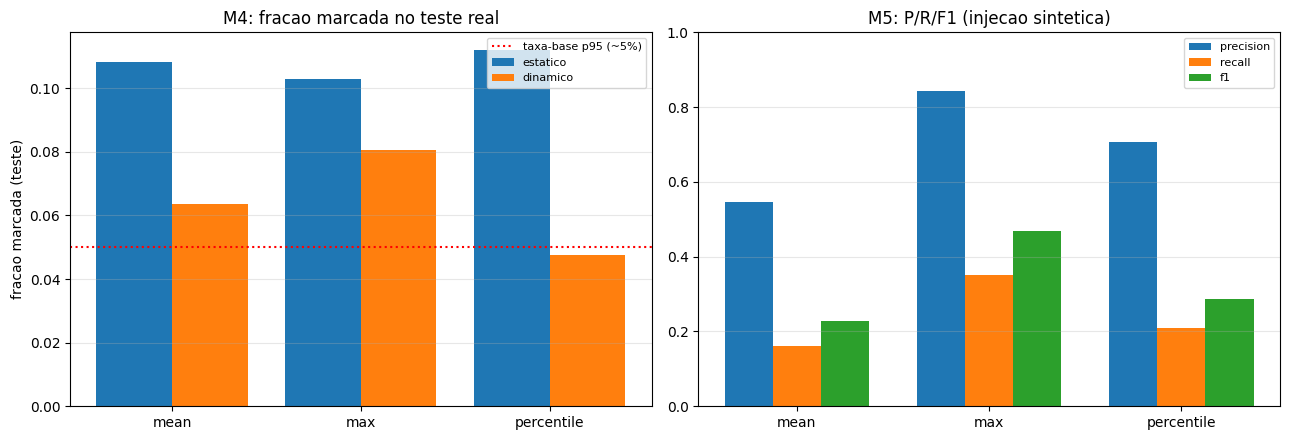

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(resumo_frac))
ax1.bar(x-0.2, resumo_frac['frac_estatico'], 0.4, label='estatico')
ax1.bar(x+0.2, resumo_frac['frac_dinamico'], 0.4, label='dinamico')
ax1.axhline(0.05, color='red', ls=':', label='taxa-base p95 (~5%)')
ax1.set_xticks(x); ax1.set_xticklabels(resumo_frac.index)
ax1.set_ylabel('fracao marcada (teste)'); ax1.set_title('M4: fracao marcada no teste real')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

x2 = np.arange(len(prf))
for i,col in enumerate(['precision','recall','f1']):
    ax2.bar(x2 + (i-1)*0.25, prf[col], 0.25, label=col)
ax2.set_xticks(x2); ax2.set_xticklabels(prf.index)
ax2.set_ylim(0,1); ax2.set_title('M5: P/R/F1 (injecao sintetica)')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)
fig.tight_layout(); save_fig(fig, 'm9_max_decisao'); plt.show()

## Conclusões e decisão

- **Fração marcada (M4):** ver Seção 2. Se `max` (com limiar recalibrado) mantém a fração
  marcada no teste próxima da taxa-base (~5%) e do dinâmico, a troca de default é **segura** ---
  o ganho de Recall não vem ao custo de marcar tudo.
- **P/R/F1 (M5):** `max` domina (Seção 3), confirmando o notebook 07.
- **Decisão:** registrada no ADR-0009/0005 e em `config.yaml` na sequência deste notebook. O
  comportamento exato (fração marcada) determina se `max` vira o default ou permanece opt-in.